In [1]:
#Quarternary model
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torch.utils.data import Subset

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Try a new model where we reduce the dataset to 4 class:
1: Pass
3: Dribble
4: Shoot
6: Defense

(Take maximum 500 videos for each classes if possible)

Discard:
Block, Run, Ball in hand, Pick, No_Action, Walk, Discard


All of the items in the Dataset:

{

	"0": "block" - 996,
	"1": "pass" - 1070,
	"2": "run" - 5924,
	"3": "dribble" - 3490,
	"4": "shoot" - 426,
	"5": "ball in hand" - 2362,
	"6": "defense" - 3866,
	"7": "pick" - 712,
	"8": "no_action" - 6490,
	"9": "walk" - 11749,
	"10": "discard" - 0
}


**1) Loading the dataset that has been processed during the Data Processing steps**

In [ ]:
#Upload to Google Drive the split_dataset.zip

!unzip /content/drive/MyDrive/Colab_Notebooks/Project/split_dataset_balanced.zip -d /content/

In [4]:
#Paths
DATA_DIR = "/content/split_dataset_balanced"
DEST_DIR_NAME = "split_dataset_balanced"
weights_path = os.path.join(DATA_DIR, "class_weights.json")

print(f"Data Directory set to: {DATA_DIR}")
print(f"Weights Path set to: {weights_path}")

Data Directory set to: /content/split_dataset_balanced
Weights Path set to: /content/split_dataset_balanced/class_weights.json


**2) Load Class Weights and Define New Label Map**

In [5]:
import json

# --- Define the 4 target classes and their sequential mapping ---
FOCUSED_CLASSES = ["pass", "dribble", "shoot", "defense"]
new_label_map = {name: i for i, name in enumerate(FOCUSED_CLASSES)}
num_classes = len(new_label_map)

# Load class counts from the new balanced JSON file
try:
    with open(weights_path, "r") as f:
        data = json.load(f)
        class_counts = data['class_counts']
except FileNotFoundError:
    print(f"Warning: {weights_path} not found. Cannot load class counts.")
    class_counts = {}

print(f"Final Number of Classes: {num_classes}")
print(f"Sequential Label Map: {new_label_map}")
print(f"Video counts in balanced set (by frame count): {class_counts}")

Final Number of Classes: 4
Sequential Label Map: {'pass': 0, 'dribble': 1, 'shoot': 2, 'defense': 3}
Video counts in balanced set (by frame count): {'pass': 8000, 'defense': 8000, 'shoot': 6816, 'dribble': 8000}


**3) Set the seed for reproducibility and fair comparison between models**

In [6]:
import random

SEED = 100  # or any number you like
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

**4) Initialize the video dataset so it can be processed for 3D CNN**

In [7]:
#Dataset class for 3DCNN
#Each sample is a stack of frames to represent a video clip
class VideoDataset3D(Dataset):
    def __init__(self, root_dir, label_map, transform=None, num_frames=16):
      """
      Initialize the 3D CNN video dataset.

      Args:
          root_dir: Root directory with subfolders for each class (e.g., block, catch, etc.)
          label_map: Dictionary mapping class names -> integer labels
          transform: Image transform to apply to each frame
          num_frames: Number of frames to load per video (to make input shape consistent)
      """
      self.samples = []  # list of (video_folder_path, label_index)
      self.transform = transform
      self.num_frames = num_frames

      # Loop through each label folder (class)
      for label in os.listdir(root_dir):
          label_path = os.path.join(root_dir, label)
          #Skip if not directory
          if not os.path.isdir(label_path):
              continue

          # Inside each class folder, loop through all video folders
          for video in os.listdir(label_path):
              video_path = os.path.join(label_path, video)
              if os.path.isdir(video_path):
                  # Store the path to the video folder and its label
                  self.samples.append((video_path, label_map[label]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        """
        Returns:
        - video_tensor: shape (C, D, H, W)
          where D = num_frames, H = height, W = width
        - label: integer class index
        """
        video_path, label = self.samples[idx]

        # Get all frame file paths for this video and sort them
        frames = sorted(os.listdir(video_path))
        frame_paths = [os.path.join(video_path, f) for f in frames if f.endswith(".jpg") or f.endswith(".png")]

        # If the video has fewer than num_frames, repeat last frame to fill
        if len(frame_paths) < self.num_frames:
            frame_paths += [frame_paths[-1]] * (self.num_frames - len(frame_paths))
        else:
            frame_paths = frame_paths[:self.num_frames]

        # Load each frame, convert to grayscale, apply transforms, and stack into a tensor
        frame_tensors = []
        for frame_path in frame_paths:
            #frame = Image.open(frame_path).convert('L')
            frame = Image.open(frame_path).convert('RGB')
            if self.transform:
                frame = self.transform(frame)
            frame_tensors.append(frame)

        # Stack frames along new "time" dimension → shape (num_frames, C, H, W)
        video_tensor = torch.stack(frame_tensors, dim=0)

        # Rearrange to match 3D CNN input convention (C, D, H, W)
        video_tensor = video_tensor.permute(1, 0, 2, 3)

        return video_tensor, label

# Transforms for each frame (resize, convert to tensor, normalize)
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

**5) Create the DataLoaders for the training, validation and testing data**

In [8]:
#We have around 37000 videos with 15 frames/videos so around 555000 images total
#This create a huge dataset, so we went to limit it by subsample the dataset
def subsample_by_class(dataset, ratio=0.1):
    class_indices = {}
    for idx, (_, label) in enumerate(dataset.samples):  # no image loading
        class_indices.setdefault(label, []).append(idx)

    selected_indices = []
    for label, indices in class_indices.items():
        n_keep = max(1, int(len(indices) * ratio))
        sampled = random.sample(indices, n_keep)
        selected_indices.extend(sampled)

    np.random.shuffle(selected_indices)
    return Subset(dataset, selected_indices)


# Create datasets for train, val, test
train_dataset = VideoDataset3D(os.path.join(DATA_DIR, "train"), new_label_map, transform)
val_dataset   = VideoDataset3D(os.path.join(DATA_DIR, "val"), new_label_map, transform)
test_dataset  = VideoDataset3D(os.path.join(DATA_DIR, "test"), new_label_map, transform)

# Subsample per class - apply 10% of dataset
train_dataset = subsample_by_class(train_dataset, 1)
val_dataset   = subsample_by_class(val_dataset, 1)
test_dataset  = subsample_by_class(test_dataset, 1)

# DataLoaders
BATCH_SIZE = 8  # smaller batch for 3D CNN (more memory)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)


In [9]:
video, label = next(iter(train_loader))
print(video.shape)  # Should be [B, C, D, H, W], Batch, Channels (1 if grayscale, 3 for RGB), Depth (# frames), Height, Width, [4, 1, 16, 64, 64]

print(label)

torch.Size([8, 3, 16, 64, 64])
tensor([1, 2, 0, 1, 2, 3, 2, 0])


**6) Define helpers function for the training**

In [10]:
# Evaluate function (returns accuracy and loss)
def evaluate(model, dataloader, device, criterion):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0

    with torch.no_grad():
        for videos, labels_batch in dataloader:  # each batch is now videos
            videos, labels_batch = videos.to(device), labels_batch.to(device, dtype=torch.long)
            outputs = model(videos)  # feed videos (not images)
            loss = criterion(outputs, labels_batch)
            total_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return accuracy, avg_loss


In [11]:
# Plotting function
def plot_training_curves(train_acc, val_acc, train_loss, val_loss):
    epochs = np.arange(1, len(train_acc) + 1)

    # Error = 1 - accuracy
    train_err = [1 - acc for acc in train_acc]
    val_err = [1 - acc for acc in val_acc]

    plt.figure(figsize=(8,5))
    plt.title("Train vs Validation Error")
    plt.plot(epochs, train_err, label="Train Error", marker='o')
    plt.plot(epochs, val_err, label="Validation Error", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,5))
    plt.title("Train vs Validation Loss")
    plt.plot(epochs, train_loss, label="Train Loss", marker='o')
    plt.plot(epochs, val_loss, label="Validation Loss", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

**7) 1st model: 3D CNN**

In [12]:
class CNN3D(nn.Module):
    def __init__(self, num_classes=4, dropout_prob=0.3):
        super(CNN3D, self).__init__()

        # 3D Conv Block 1: input channels=1 (Grayscale), output=16
        self.conv1 = nn.Conv3d(1, 16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm3d(16)

        # 3D Conv Block 2: 16 -> 32 channels
        self.conv2 = nn.Conv3d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm3d(32)

        # 3D Conv Block 3: 32 -> 64 channels
        self.conv3 = nn.Conv3d(32, 64, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm3d(64)

        # 3D Max Pooling (reduce spatial and temporal dimensions)
        self.pool  = nn.MaxPool3d(kernel_size=2, stride=2)

        # Fully connected layers
        # Compute : after 3 poolings, input D,H,W = 16,64,64 → 8,32,32 → 4,16,16 → 2,8,8
        self.fc1 = nn.Linear(64*2*8*8, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        # Conv Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        # Conv Block 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        # Conv Block 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


**8) Training implementation for the primary model**

In [13]:
def train_3dcnn(model, train_loader, val_loader, device, total_epochs=10, lr=1e-3, batch_size=16):

    # Move model to device
    model = model.to(device)
    print(f"Using device: {device}")

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Metrics tracking
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    # Initialize tracker for best performance
    best_val_acc = 0.0

    training_start_time = time.time()

    for epoch in range(total_epochs):
        epoch_start_time = time.time()
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for videos, labels_batch in train_loader:
            videos, labels_batch = videos.to(device), labels_batch.to(device, dtype=torch.long)

            optimizer.zero_grad()
            outputs = model(videos)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

        # Train metrics
        avg_train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # Validation metrics
        val_acc, val_loss = evaluate(model, val_loader, device, criterion)

        # Save the model if it performs better on the validation set
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_path = f"best_cnn3d_ep{total_epochs}_bs{batch_size}_lr{lr:.0e}_acc{best_val_acc:.4f}.pth"
            full_path = os.path.join("checkpoints", save_path)
            os.makedirs("checkpoints", exist_ok=True)
            torch.save(model.state_dict(), full_path)
            print(f"CHECKPOINT: Saved new best model (Val Acc = {best_val_acc:.4f})")

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        epoch_time = time.time() - epoch_start_time

        print(f"Epoch {epoch+1}/{total_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Time: {epoch_time:.2f} sec")

    training_end_time = time.time()
    print("Training complete.")
    print(f"Total training time: {training_end_time - training_start_time:.2f} seconds")
    print(f"Best saved Validation Accuracy: {best_val_acc:.4f}")
    return model, train_losses, val_losses, train_accs, val_accs


**9) Instantiate the model and train it**

Using device: cuda
Epoch 1/10 | Train Loss: 1.7037 | Train Acc: 0.3896 | Val Loss: 1.2312 | Val Acc: 0.4375 | Time: 23.33 sec
Epoch 2/10 | Train Loss: 1.1751 | Train Acc: 0.4494 | Val Loss: 1.1260 | Val Acc: 0.5260 | Time: 22.51 sec
Epoch 3/10 | Train Loss: 1.1502 | Train Acc: 0.4961 | Val Loss: 1.0669 | Val Acc: 0.5573 | Time: 21.91 sec
Epoch 4/10 | Train Loss: 1.0970 | Train Acc: 0.5338 | Val Loss: 1.0688 | Val Acc: 0.5104 | Time: 21.97 sec
Epoch 5/10 | Train Loss: 1.0608 | Train Acc: 0.5260 | Val Loss: 1.0116 | Val Acc: 0.5312 | Time: 21.95 sec
Epoch 6/10 | Train Loss: 0.9759 | Train Acc: 0.5708 | Val Loss: 0.9660 | Val Acc: 0.5469 | Time: 22.31 sec
Epoch 7/10 | Train Loss: 0.9721 | Train Acc: 0.5773 | Val Loss: 1.0801 | Val Acc: 0.5312 | Time: 21.65 sec
Epoch 8/10 | Train Loss: 0.8955 | Train Acc: 0.6188 | Val Loss: 0.9459 | Val Acc: 0.5781 | Time: 20.80 sec
Epoch 9/10 | Train Loss: 0.8314 | Train Acc: 0.6461 | Val Loss: 0.9699 | Val Acc: 0.5990 | Time: 22.37 sec
Epoch 10/10 | Trai

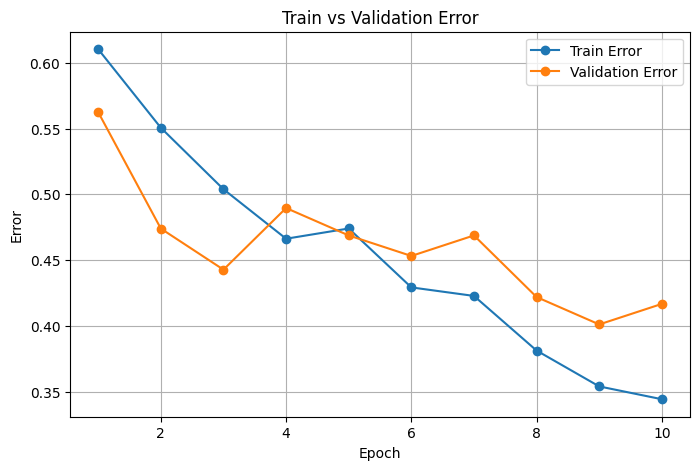

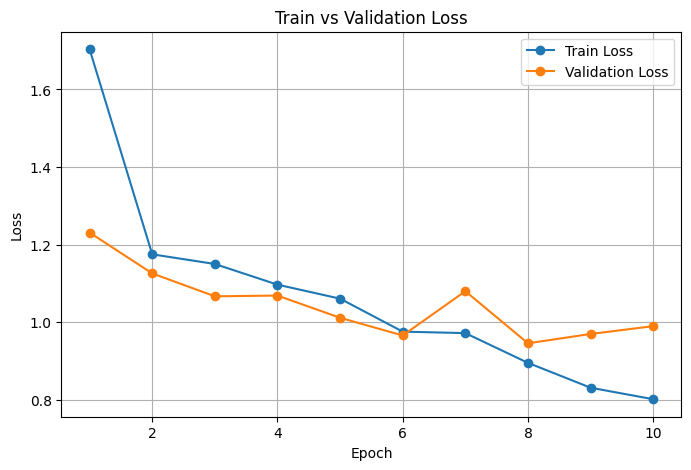

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = CNN3D(num_classes=4, dropout_prob=0.3)
model1 = model1.to(device)

model1, train_losses, val_losses, train_accs, val_accs = train_3dcnn(
    model1, train_loader, val_loader, device, total_epochs=10, lr=1e-3
)

plot_training_curves(train_accs, val_accs, train_losses, val_losses)



**10) Test the 3D CNN with 4 classes instead of 10 classes**

Using device: cuda
Epoch 1/25 | Train Loss: 1.7711 | Train Acc: 0.3649 | Val Loss: 1.2199 | Val Acc: 0.4062 | Time: 22.12 sec
Epoch 2/25 | Train Loss: 1.1888 | Train Acc: 0.4292 | Val Loss: 1.1529 | Val Acc: 0.4792 | Time: 22.19 sec
Epoch 3/25 | Train Loss: 1.1715 | Train Acc: 0.4669 | Val Loss: 1.1490 | Val Acc: 0.4688 | Time: 21.83 sec
Epoch 4/25 | Train Loss: 1.1233 | Train Acc: 0.4766 | Val Loss: 1.0811 | Val Acc: 0.4792 | Time: 22.65 sec
Epoch 5/25 | Train Loss: 1.0940 | Train Acc: 0.5117 | Val Loss: 1.0427 | Val Acc: 0.5208 | Time: 21.37 sec
Epoch 6/25 | Train Loss: 1.0752 | Train Acc: 0.5234 | Val Loss: 0.9859 | Val Acc: 0.5469 | Time: 22.91 sec
Epoch 7/25 | Train Loss: 1.0030 | Train Acc: 0.5695 | Val Loss: 1.0549 | Val Acc: 0.5000 | Time: 21.57 sec
Epoch 8/25 | Train Loss: 0.9696 | Train Acc: 0.5779 | Val Loss: 0.9352 | Val Acc: 0.5781 | Time: 21.39 sec
Epoch 9/25 | Train Loss: 0.9223 | Train Acc: 0.5896 | Val Loss: 1.0961 | Val Acc: 0.5417 | Time: 21.73 sec
Epoch 10/25 | Trai

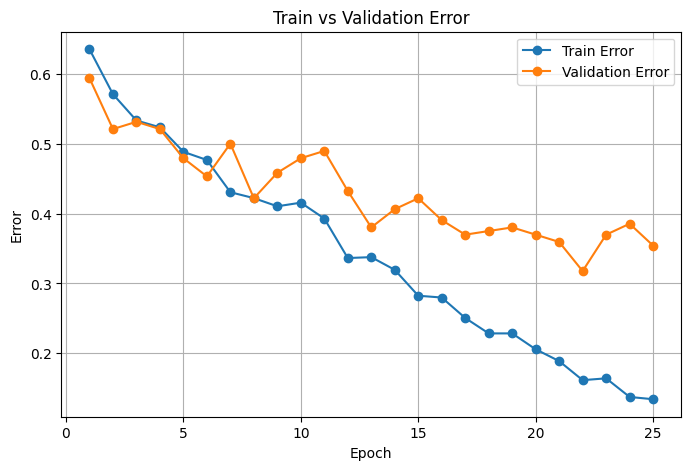

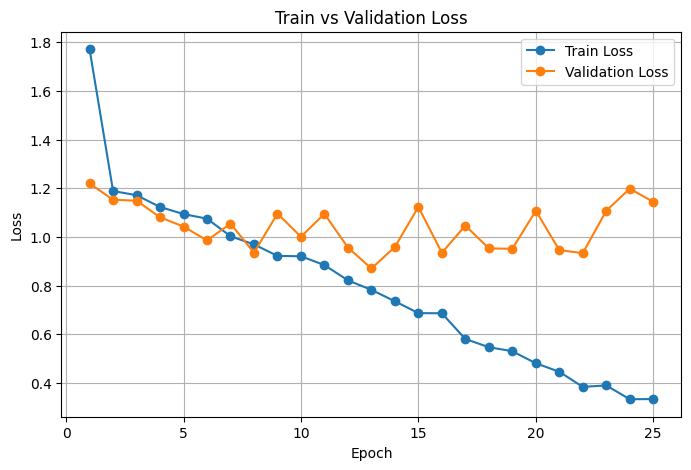

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2 = CNN3D(num_classes=4, dropout_prob=0.3)
model2 = model2.to(device)

model2, train_losses, val_losses, train_accs, val_accs = train_3dcnn(
    model2, train_loader, val_loader, device, total_epochs=25, lr=1e-3
)

plot_training_curves(train_accs, val_accs, train_losses, val_losses)

**11) Try a different learning rate (Managed to achieve 67% val accuracy)**

Using device: cuda
Epoch 1/10 | Train Loss: 1.2778 | Train Acc: 0.4013 | Val Loss: 1.1165 | Val Acc: 0.5625 | Time: 22.33 sec
Epoch 2/10 | Train Loss: 1.1001 | Train Acc: 0.5123 | Val Loss: 1.0417 | Val Acc: 0.5469 | Time: 21.63 sec
Epoch 3/10 | Train Loss: 1.0161 | Train Acc: 0.5500 | Val Loss: 0.9753 | Val Acc: 0.5729 | Time: 22.59 sec
Epoch 4/10 | Train Loss: 0.9424 | Train Acc: 0.6117 | Val Loss: 0.9588 | Val Acc: 0.6042 | Time: 21.89 sec
Epoch 5/10 | Train Loss: 0.8748 | Train Acc: 0.6364 | Val Loss: 0.9376 | Val Acc: 0.5938 | Time: 21.58 sec
Epoch 6/10 | Train Loss: 0.8146 | Train Acc: 0.6649 | Val Loss: 0.8604 | Val Acc: 0.6562 | Time: 21.61 sec
Epoch 7/10 | Train Loss: 0.7201 | Train Acc: 0.7201 | Val Loss: 0.8393 | Val Acc: 0.6510 | Time: 21.99 sec
Epoch 8/10 | Train Loss: 0.6747 | Train Acc: 0.7370 | Val Loss: 0.8388 | Val Acc: 0.6302 | Time: 22.24 sec
Epoch 9/10 | Train Loss: 0.6076 | Train Acc: 0.7513 | Val Loss: 0.7922 | Val Acc: 0.6771 | Time: 21.99 sec
Epoch 10/10 | Trai

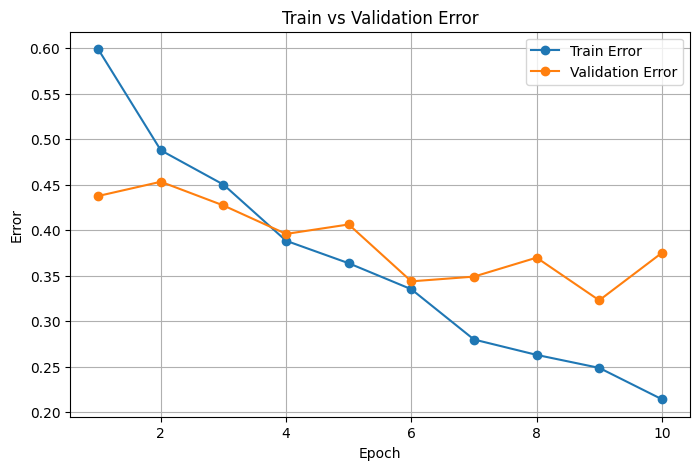

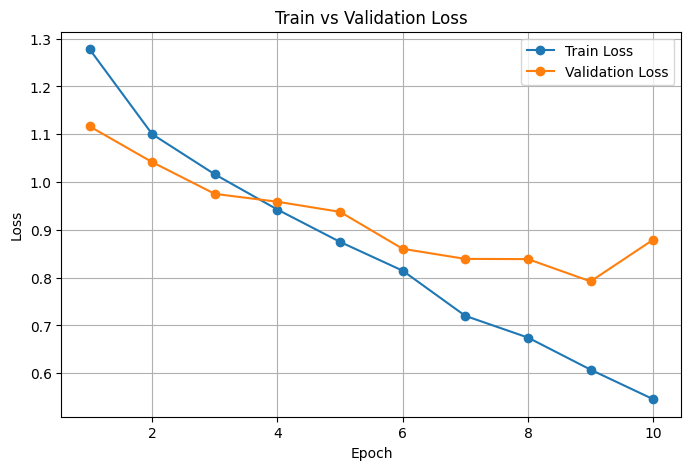

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = CNN3D(num_classes=4, dropout_prob=0.3)
model1 = model1.to(device)

model1, train_losses, val_losses, train_accs, val_accs = train_3dcnn(
    model1, train_loader, val_loader, device, total_epochs=10, lr=1e-4
)

plot_training_curves(train_accs, val_accs, train_losses, val_losses)



**12) Changed the 3DCNN architecture**

In [ ]:
class CNN3D_v2(nn.Module):
    def __init__(self, num_classes=4, dropout_prob=0.4): # Increased dropout
        super(CNN3D_v2, self).__init__()

        # 3D Conv Blocks (unchanged)
        self.conv1 = nn.Conv3d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm3d(32)
        self.conv2 = nn.Conv3d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm3d(64)
        self.conv3 = nn.Conv3d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm3d(128)
        self.conv4 = nn.Conv3d(128, 256, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm3d(256)
        self.pool  = nn.MaxPool3d(kernel_size=2, stride=2)

        # Fully connected layers
        self.fc1 = nn.Linear(256*1*4*4, 2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, num_classes)

        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        # Conv Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        # Conv Block 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        # Conv Block 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        # Conv Block 4
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        # Flatten
        x = x.view(x.size(0), -1)
        # FC layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        x = self.fc3(x)
        return x

**Also managed to achieve 67% val accuracy with the new architecture of 3D CNN**

Using device: cuda
Epoch 1/10 | Train Loss: 1.3684 | Train Acc: 0.4026 | Val Loss: 1.1198 | Val Acc: 0.5052 | Time: 22.88 sec
Epoch 2/10 | Train Loss: 1.1023 | Train Acc: 0.5260 | Val Loss: 1.0407 | Val Acc: 0.5677 | Time: 22.04 sec
Epoch 3/10 | Train Loss: 1.0100 | Train Acc: 0.5792 | Val Loss: 1.0324 | Val Acc: 0.5729 | Time: 23.92 sec
Epoch 4/10 | Train Loss: 0.9374 | Train Acc: 0.6156 | Val Loss: 0.9266 | Val Acc: 0.5885 | Time: 22.69 sec
Epoch 5/10 | Train Loss: 0.8751 | Train Acc: 0.6383 | Val Loss: 1.0182 | Val Acc: 0.5469 | Time: 24.43 sec
Epoch 6/10 | Train Loss: 0.8203 | Train Acc: 0.6500 | Val Loss: 0.8507 | Val Acc: 0.6458 | Time: 21.87 sec
Epoch 7/10 | Train Loss: 0.7067 | Train Acc: 0.7091 | Val Loss: 0.8401 | Val Acc: 0.6250 | Time: 22.90 sec
Epoch 8/10 | Train Loss: 0.6668 | Train Acc: 0.7260 | Val Loss: 0.8190 | Val Acc: 0.6771 | Time: 22.77 sec
Epoch 9/10 | Train Loss: 0.6227 | Train Acc: 0.7578 | Val Loss: 0.9770 | Val Acc: 0.5521 | Time: 21.98 sec
Epoch 10/10 | Trai

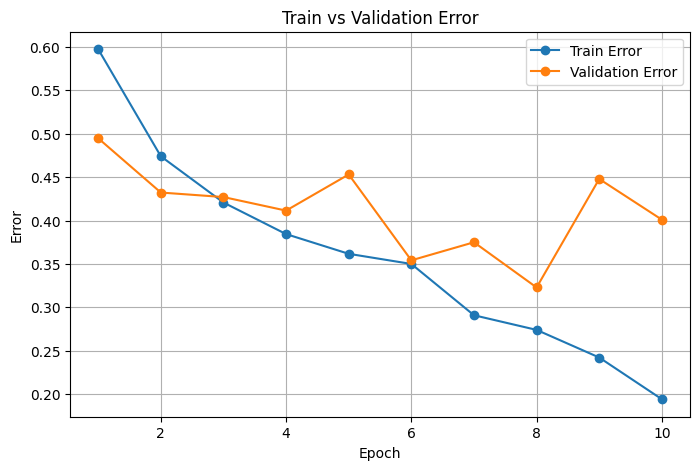

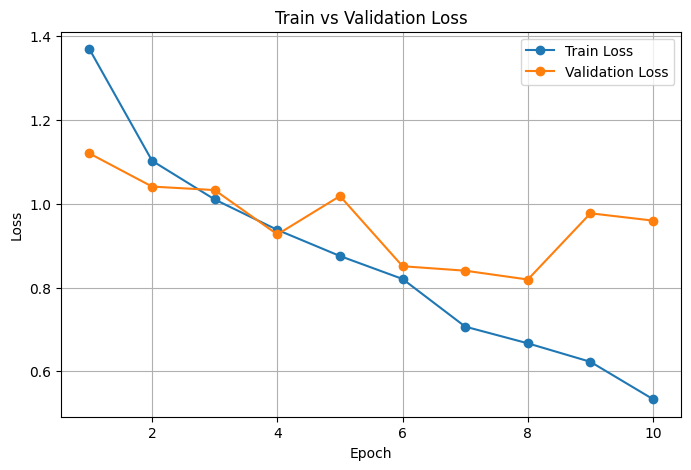

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model3 = CNN3D_v2(num_classes=4, dropout_prob=0.4)
model3 = model3.to(device)

model3, train_losses, val_losses, train_accs, val_accs = train_3dcnn(
    model3, train_loader, val_loader, device, total_epochs=10, lr=1e-4
)

plot_training_curves(train_accs, val_accs, train_losses, val_losses)



**13) Full Fine-Tuning Model: Training of Pre-Trained R(2+1)D-18 (adaptation of the pre-trained weights)**



In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights

# --- Configuration ---
NUM_CLASSES = 4
DROPOUT_PROB = 0.5

class FineTunedR2Plus1D(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout_prob=DROPOUT_PROB):
        super().__init__()

        # 1. Load the pre-trained model on Kinetics-400
        weights = R2Plus1D_18_Weights.KINETICS400_V1
        model = r2plus1d_18(weights=weights)

        # 2. Modify the first convolutional layer (from 3 channels to 1 channel - Grayscale)
        old_conv1 = model.stem[0]
        new_conv1 = nn.Conv3d(
            in_channels=1, # Change to 1 for grayscale input
            out_channels=old_conv1.out_channels,
            kernel_size=old_conv1.kernel_size,
            stride=old_conv1.stride,
            padding=old_conv1.padding,
            bias=False
        )
        model.stem[0] = new_conv1

        # 3. Replace the final classifier layer ('fc')
        num_ftrs = model.fc.in_features #512

        # New slightly deeper head to help adaptation
        self.fc_head = nn.Sequential(
            nn.Dropout(dropout_prob),
            nn.Linear(num_ftrs, 1024), # Deeper Hidden Layer
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(1024, num_classes) # Final output == 4 classes
        )
        model.fc = self.fc_head # Replace the original single FC layer

        # 4. Keep the entire network UN-FROZEN for full fine-tuning
        self.model = model

    def forward(self, x):
        # x shape: (B, 1, D, H, W) = (Batch, Channel, Depth, Height, Width)
        return self.model(x)

In [15]:
# --- Evaluate function ---
# Evaluate function (returns accuracy and loss)
def evaluate(model, dataloader, device, criterion):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0

    with torch.no_grad():
        for videos, labels_batch in dataloader:  # each batch is now videos
            videos, labels_batch = videos.to(device), labels_batch.to(device, dtype=torch.long)
            outputs = model(videos)  # feed videos (not images)
            loss = criterion(outputs, labels_batch)
            total_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return accuracy, avg_loss


In [16]:
# --- Plotting Function ---
# Plotting function
def plot_training_curves(train_acc, val_acc, train_loss, val_loss):
    epochs = np.arange(1, len(train_acc) + 1)

    # Error = 1 - accuracy
    train_err = [1 - acc for acc in train_acc]
    val_err = [1 - acc for acc in val_acc]

    plt.figure(figsize=(8,5))
    plt.title("Train vs Validation Error")
    plt.plot(epochs, train_err, label="Train Error", marker='o')
    plt.plot(epochs, val_err, label="Validation Error", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,5))
    plt.title("Train vs Validation Loss")
    plt.plot(epochs, train_loss, label="Train Loss", marker='o')
    plt.plot(epochs, val_loss, label="Validation Loss", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

**First Train function implemented for the fine-tuning model**

In [ ]:
# --- Train Function ---
def train_r2plus1d_finetune(model, train_loader, val_loader, device, total_epochs=10, lr=1e-3, batch_size=8):

    # Move model to device
    model = model.to(device)
    print(f"Using device: {device}")

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Scheduler
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

    # Metrics tracking
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    # Initialize tracker for best performance
    best_val_acc = 0.0

    training_start_time = time.time()

    for epoch in range(total_epochs):
        epoch_start_time = time.time()
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for videos, labels_batch in train_loader:
            videos, labels_batch = videos.to(device), labels_batch.to(device, dtype=torch.long)

            optimizer.zero_grad()
            outputs = model(videos)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

        # Train metrics
        avg_train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # Validation metrics
        val_acc, val_loss = evaluate(model, val_loader, device, criterion)

        # Step the scheduler
        scheduler.step()

        # Save the model if it performs better on the validation set
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_path = f"train_r2plus1d_ep{total_epochs}_bs{batch_size}_lr{lr:.0e}_acc{best_val_acc:.4f}.pth"
            full_path = os.path.join("checkpoints", save_path)
            os.makedirs("checkpoints", exist_ok=True)
            torch.save(model.state_dict(), full_path)
            print(f"CHECKPOINT: Saved new best model (Val Acc = {best_val_acc:.4f})")

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        epoch_time = time.time() - epoch_start_time

        print(f"Epoch {epoch+1}/{total_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Time: {epoch_time:.2f} sec | LR: {optimizer.param_groups[0]['lr']:.0e}")

    training_end_time = time.time()
    print("Training complete.")
    print(f"Total training time: {training_end_time - training_start_time:.2f} seconds")
    print(f"Best saved Validation Accuracy: {best_val_acc:.4f}")
    return model, train_losses, val_losses, train_accs, val_accs


**1st Test (83.33% validation accuracy)**

Downloading: "https://download.pytorch.org/models/r2plus1d_18-91a641e6.pth" to /root/.cache/torch/hub/checkpoints/r2plus1d_18-91a641e6.pth


100%|██████████| 120M/120M [00:00<00:00, 190MB/s]


Using device: cuda
CHECKPOINT: Saved new best model (Val Acc = 0.6510)
Epoch 1/15 | Train Loss: 1.2178 | Train Acc: 0.4377 | Val Loss: 0.9109 | Val Acc: 0.6510 | Time: 78.01 sec | LR: 1e-04
CHECKPOINT: Saved new best model (Val Acc = 0.7135)
Epoch 2/15 | Train Loss: 0.8340 | Train Acc: 0.6669 | Val Loss: 0.7274 | Val Acc: 0.7135 | Time: 79.11 sec | LR: 1e-04
Epoch 3/15 | Train Loss: 0.6010 | Train Acc: 0.7714 | Val Loss: 1.2529 | Val Acc: 0.6198 | Time: 78.98 sec | LR: 1e-04
CHECKPOINT: Saved new best model (Val Acc = 0.7240)
Epoch 4/15 | Train Loss: 0.4699 | Train Acc: 0.8286 | Val Loss: 0.6359 | Val Acc: 0.7240 | Time: 80.08 sec | LR: 1e-04
CHECKPOINT: Saved new best model (Val Acc = 0.7448)
Epoch 5/15 | Train Loss: 0.3118 | Train Acc: 0.9032 | Val Loss: 0.7045 | Val Acc: 0.7448 | Time: 80.65 sec | LR: 1e-04
CHECKPOINT: Saved new best model (Val Acc = 0.7656)
Epoch 6/15 | Train Loss: 0.2265 | Train Acc: 0.9260 | Val Loss: 0.8035 | Val Acc: 0.7656 | Time: 82.08 sec | LR: 1e-04
CHECKPO

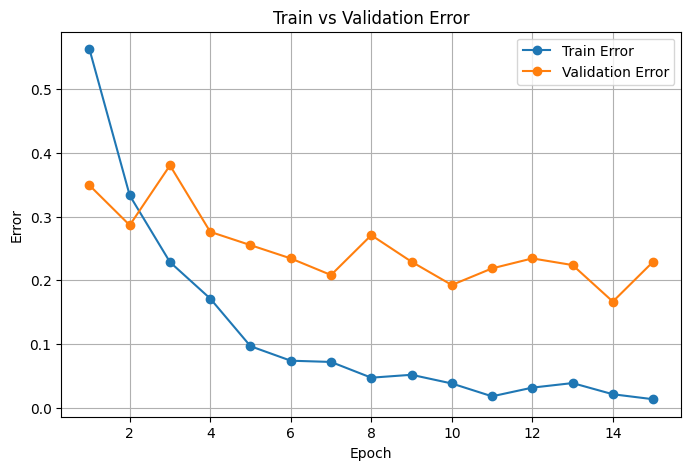

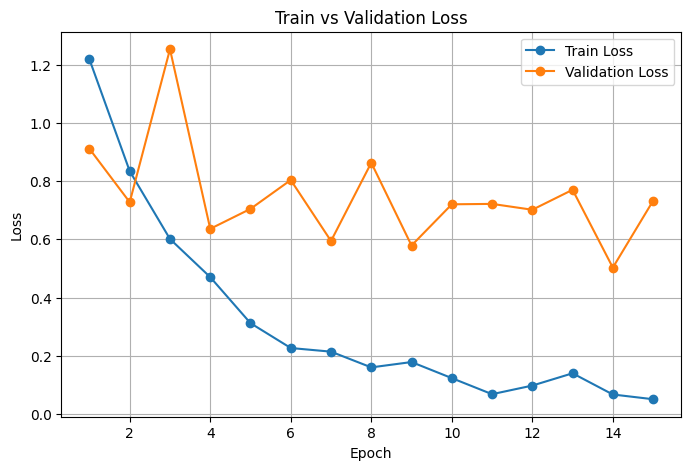

In [ ]:
#1st model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the fine-tuning model
ft_model1 = FineTunedR2Plus1D(num_classes=4, dropout_prob=0.5)
ft_model1 = ft_model1.to(device)

# Train the model using a low learning rate (1e-4) for full fine-tuning
ft_model1, train_losses, val_losses, train_accs, val_accs = train_r2plus1d_finetune(
    ft_model1,
    train_loader,
    val_loader,
    device,
    total_epochs=15,  #Try 15 epochs
    lr=1e-4,         # Low learning rate for fine-tuning
    batch_size=8
)

# Plot the training curves
plot_training_curves(train_accs, val_accs, train_losses, val_losses)

**2nd Test (Reduce the learning rate) (84.38% validation accuracy)**

Using device: cuda
CHECKPOINT: Saved new best model (Val Acc = 0.6094)
Epoch 1/15 | Train Loss: 1.2502 | Train Acc: 0.4136 | Val Loss: 0.9796 | Val Acc: 0.6094 | Time: 76.17 sec | LR: 5e-05
CHECKPOINT: Saved new best model (Val Acc = 0.6719)
Epoch 2/15 | Train Loss: 0.9844 | Train Acc: 0.5896 | Val Loss: 0.7648 | Val Acc: 0.6719 | Time: 78.62 sec | LR: 5e-05
CHECKPOINT: Saved new best model (Val Acc = 0.6875)
Epoch 3/15 | Train Loss: 0.6125 | Train Acc: 0.7682 | Val Loss: 0.7822 | Val Acc: 0.6875 | Time: 79.49 sec | LR: 5e-05
CHECKPOINT: Saved new best model (Val Acc = 0.7552)
Epoch 4/15 | Train Loss: 0.3812 | Train Acc: 0.8701 | Val Loss: 0.7427 | Val Acc: 0.7552 | Time: 80.58 sec | LR: 5e-05
CHECKPOINT: Saved new best model (Val Acc = 0.7708)
Epoch 5/15 | Train Loss: 0.2825 | Train Acc: 0.9071 | Val Loss: 0.6294 | Val Acc: 0.7708 | Time: 81.23 sec | LR: 5e-05
CHECKPOINT: Saved new best model (Val Acc = 0.7760)
Epoch 6/15 | Train Loss: 0.2671 | Train Acc: 0.9045 | Val Loss: 0.6365 | V

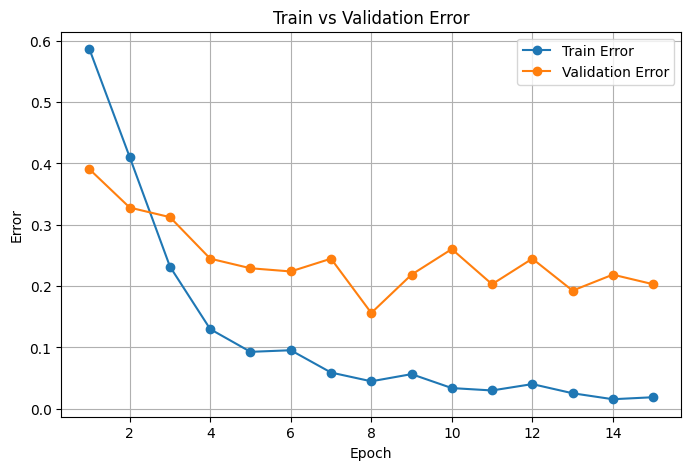

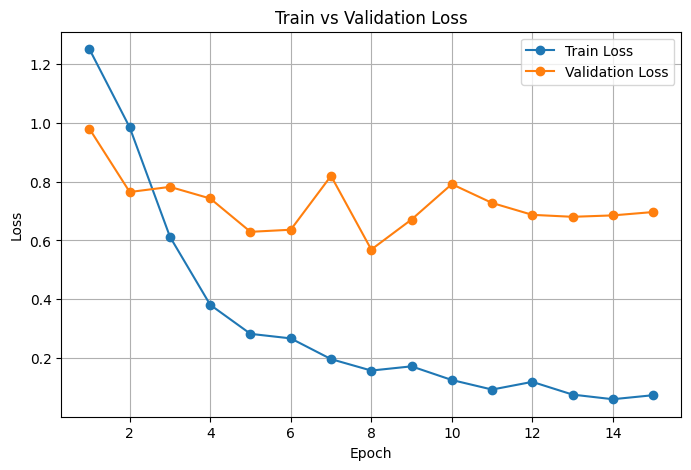

In [ ]:
#2nd model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the fine-tuning model
ft_model2 = FineTunedR2Plus1D(num_classes=4, dropout_prob=0.5)
ft_model2 = ft_model2.to(device)

# Train the model
ft_model2, train_losses, val_losses, train_accs, val_accs = train_r2plus1d_finetune(
    ft_model2,
    train_loader,
    val_loader,
    device,
    total_epochs=15,  #Try 15 epochs
    lr=5e-5,         # Low learning rate for fine-tuning
    batch_size=8
)

# Plot the training curves
plot_training_curves(train_accs, val_accs, train_losses, val_losses)

**3rd Test (Increase the dropout rate) (81.25% validation accuracy)**

Using device: cuda
CHECKPOINT: Saved new best model (Val Acc = 0.5417)
Epoch 1/15 | Train Loss: 1.4379 | Train Acc: 0.3091 | Val Loss: 1.1167 | Val Acc: 0.5417 | Time: 76.71 sec | LR: 5e-05
CHECKPOINT: Saved new best model (Val Acc = 0.6615)
Epoch 2/15 | Train Loss: 1.1336 | Train Acc: 0.4994 | Val Loss: 0.8546 | Val Acc: 0.6615 | Time: 78.45 sec | LR: 5e-05
CHECKPOINT: Saved new best model (Val Acc = 0.7031)
Epoch 3/15 | Train Loss: 0.8914 | Train Acc: 0.6234 | Val Loss: 0.7488 | Val Acc: 0.7031 | Time: 80.17 sec | LR: 5e-05
CHECKPOINT: Saved new best model (Val Acc = 0.7500)
Epoch 4/15 | Train Loss: 0.6702 | Train Acc: 0.7448 | Val Loss: 0.6949 | Val Acc: 0.7500 | Time: 80.91 sec | LR: 5e-05
Epoch 5/15 | Train Loss: 0.4813 | Train Acc: 0.8260 | Val Loss: 0.6829 | Val Acc: 0.7396 | Time: 81.70 sec | LR: 5e-05
Epoch 6/15 | Train Loss: 0.3857 | Train Acc: 0.8649 | Val Loss: 0.7020 | Val Acc: 0.7500 | Time: 81.27 sec | LR: 5e-05
Epoch 7/15 | Train Loss: 0.3326 | Train Acc: 0.8935 | Val L

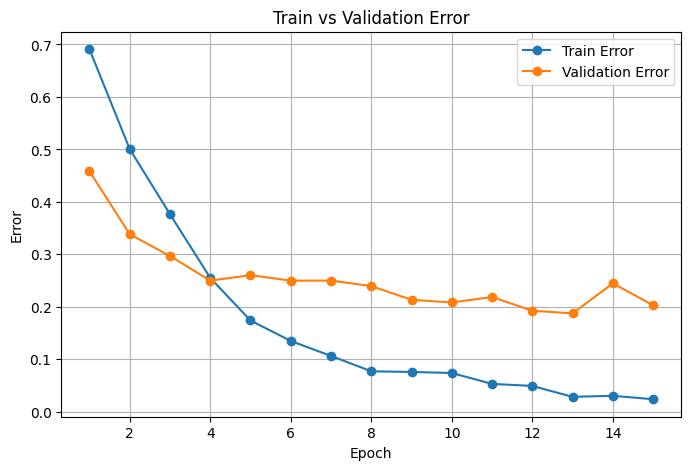

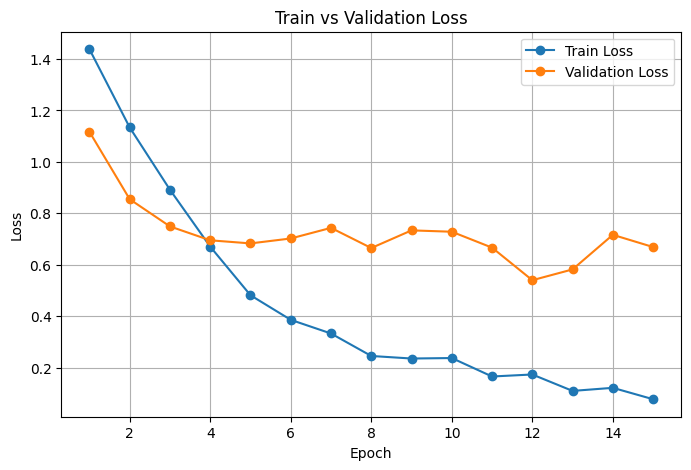

In [ ]:
#3nd model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the fine-tuning model
ft_model3 = FineTunedR2Plus1D(num_classes=4, dropout_prob=0.7)
ft_model3 = ft_model3.to(device)

# Train the model using a low learning rate (1e-4) for full fine-tuning
ft_model3, train_losses, val_losses, train_accs, val_accs = train_r2plus1d_finetune(
    ft_model3,
    train_loader,
    val_loader,
    device,
    total_epochs=15,  #Try 15 epochs
    lr=5e-5,         # Low learning rate for fine-tuning
    batch_size=8
)

# Plot the training curves
plot_training_curves(train_accs, val_accs, train_losses, val_losses)

**14) Full Fine-Tuning Model: Training of Pre-Trained R(2+1)D-18 (Have weight decay to the train function)**

In [17]:
# --- Train Function ---
def train_r2plus1d_finetune(model, train_loader, val_loader, device, total_epochs=10, lr=1e-3, batch_size=8, model_name_str="r2plus1d_ft"):

    # Move model to device
    model = model.to(device)
    print(f"Using device: {device}")

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # Scheduler
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    # Metrics tracking
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    # Initialize tracker for best performance
    best_val_acc = 0.0

    training_start_time = time.time()

    for epoch in range(total_epochs):
        epoch_start_time = time.time()
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for videos, labels_batch in train_loader:
            videos, labels_batch = videos.to(device), labels_batch.to(device, dtype=torch.long)

            optimizer.zero_grad()
            outputs = model(videos)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

        # Train metrics
        avg_train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # Validation metrics
        val_acc, val_loss = evaluate(model, val_loader, device, criterion)

        # Step the scheduler
        scheduler.step()

        # Save the model if it performs better on the validation set
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_path = f"train_r2plus1d_{model_name_str}_ep{total_epochs}_bs{batch_size}_lr{lr:.0e}_acc{best_val_acc:.4f}.pth"
            full_path = os.path.join("checkpoints", save_path)
            os.makedirs("checkpoints", exist_ok=True)
            torch.save(model.state_dict(), full_path)
            print(f"CHECKPOINT: Saved new best model (Val Acc = {best_val_acc:.4f})")

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        epoch_time = time.time() - epoch_start_time

        print(f"Epoch {epoch+1}/{total_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Time: {epoch_time:.2f} sec | LR: {optimizer.param_groups[0]['lr']:.0e}")

    training_end_time = time.time()
    print("Training complete.")
    print(f"Total training time: {training_end_time - training_start_time:.2f} seconds")
    print(f"Best saved Validation Accuracy: {best_val_acc:.4f}")
    return model, train_losses, val_losses, train_accs, val_accs


**4th test (84.38% validation accuracy)**

Using device: cuda
CHECKPOINT: Saved new best model (Val Acc = 0.6302)
Epoch 1/20 | Train Loss: 1.3239 | Train Acc: 0.3714 | Val Loss: 0.9836 | Val Acc: 0.6302 | Time: 77.69 sec | LR: 5e-05
CHECKPOINT: Saved new best model (Val Acc = 0.7344)
Epoch 2/20 | Train Loss: 0.9495 | Train Acc: 0.6097 | Val Loss: 0.6694 | Val Acc: 0.7344 | Time: 79.60 sec | LR: 5e-05
Epoch 3/20 | Train Loss: 0.6825 | Train Acc: 0.7455 | Val Loss: 0.7039 | Val Acc: 0.7083 | Time: 80.56 sec | LR: 5e-05
CHECKPOINT: Saved new best model (Val Acc = 0.7812)
Epoch 4/20 | Train Loss: 0.4281 | Train Acc: 0.8558 | Val Loss: 0.6364 | Val Acc: 0.7812 | Time: 80.95 sec | LR: 5e-05
Epoch 5/20 | Train Loss: 0.3496 | Train Acc: 0.8896 | Val Loss: 0.6749 | Val Acc: 0.7708 | Time: 81.24 sec | LR: 5e-05
Epoch 6/20 | Train Loss: 0.2569 | Train Acc: 0.9169 | Val Loss: 0.6953 | Val Acc: 0.7760 | Time: 80.85 sec | LR: 5e-05
CHECKPOINT: Saved new best model (Val Acc = 0.7969)
Epoch 7/20 | Train Loss: 0.2329 | Train Acc: 0.9260 | Val L

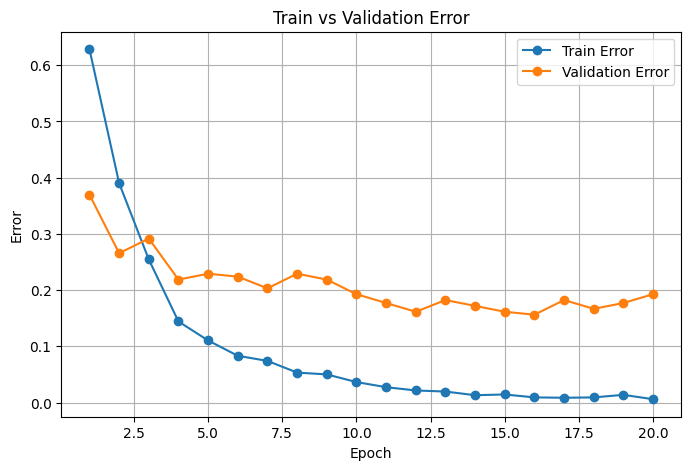

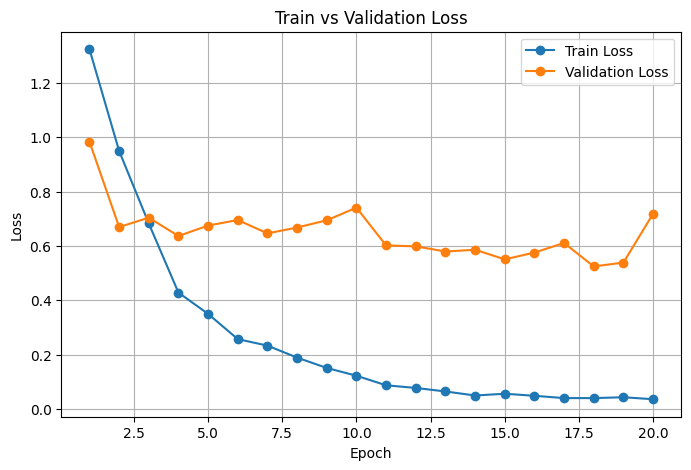

In [ ]:
#4th model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the fine-tuning model
ft_model4 = FineTunedR2Plus1D(num_classes=4, dropout_prob=0.6)
ft_model4 = ft_model4.to(device)

# Train the model using a low learning rate (1e-4) for full fine-tuning
ft_model4, train_losses, val_losses, train_accs, val_accs = train_r2plus1d_finetune(
    ft_model4,
    train_loader,
    val_loader,
    device,
    total_epochs=20,
    lr=5e-5,         # Low learning rate for fine-tuning
    batch_size=8,
    model_name_str="ft_model4"
)

# Plot the training curves
plot_training_curves(train_accs, val_accs, train_losses, val_losses)

**15) Full Fine-Tuning Model: Training of Pre-Trained R(2+1)D-18 (Change the Channel dimension from 1 (greyscale) to 3 (RGB) + Add extra layers for the final classification)**


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights

# --- Configuration ---
NUM_CLASSES = 4
DROPOUT_PROB = 0.5

class FineTunedR2Plus1D(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout_prob=DROPOUT_PROB):
        super().__init__()

        # 1. Load the pre-trained model on Kinetics-400
        weights = R2Plus1D_18_Weights.KINETICS400_V1
        model = r2plus1d_18(weights=weights)

        # 2. Have the 1st conv layer to accept RGB input
        old_conv1 = model.stem[0]
        new_conv1 = nn.Conv3d(
            in_channels=3, # Change to 3 for RGB input
            out_channels=old_conv1.out_channels,
            kernel_size=old_conv1.kernel_size,
            stride=old_conv1.stride,
            padding=old_conv1.padding,
            bias=False
        )
        model.stem[0] = new_conv1


        # 3. Replace the final classifier layer ('fc')
        num_ftrs = model.fc.in_features #512

        # New slightly deeper head to help adaptation
        self.fc_head = nn.Sequential(
            nn.Dropout(dropout_prob),
            nn.Linear(num_ftrs, 1024), # Deeper Hidden Layer
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(1024, 512),   # New extra layer
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(512, num_classes)  # Final output == 4 classes
        )

        model.fc = self.fc_head # Replace the original single FC layer

        # 4. Keep the entire network UN-FROZEN for full fine-tuning
        self.model = model

    def forward(self, x):
        # x shape: (B, 1, D, H, W) = (Batch, Channel, Depth, Height, Width)
        return self.model(x)

**5th Test (86.46% validation accuracy) - Best Result**

Using device: cuda
CHECKPOINT: Saved new best model (Val Acc = 0.5365)
Epoch 1/20 | Train Loss: 1.3280 | Train Acc: 0.3448 | Val Loss: 1.1029 | Val Acc: 0.5365 | Time: 83.27 sec | LR: 1e-04
CHECKPOINT: Saved new best model (Val Acc = 0.6406)
Epoch 2/20 | Train Loss: 1.0884 | Train Acc: 0.5390 | Val Loss: 0.8581 | Val Acc: 0.6406 | Time: 84.88 sec | LR: 1e-04
CHECKPOINT: Saved new best model (Val Acc = 0.6927)
Epoch 3/20 | Train Loss: 0.8677 | Train Acc: 0.6604 | Val Loss: 0.7182 | Val Acc: 0.6927 | Time: 86.03 sec | LR: 1e-04
CHECKPOINT: Saved new best model (Val Acc = 0.7708)
Epoch 4/20 | Train Loss: 0.6296 | Train Acc: 0.7740 | Val Loss: 0.6120 | Val Acc: 0.7708 | Time: 85.73 sec | LR: 1e-04
Epoch 5/20 | Train Loss: 0.5505 | Train Acc: 0.8039 | Val Loss: 0.6242 | Val Acc: 0.7448 | Time: 86.55 sec | LR: 1e-04
CHECKPOINT: Saved new best model (Val Acc = 0.7812)
Epoch 6/20 | Train Loss: 0.3810 | Train Acc: 0.8675 | Val Loss: 0.6835 | Val Acc: 0.7812 | Time: 85.88 sec | LR: 1e-04
Epoch 7

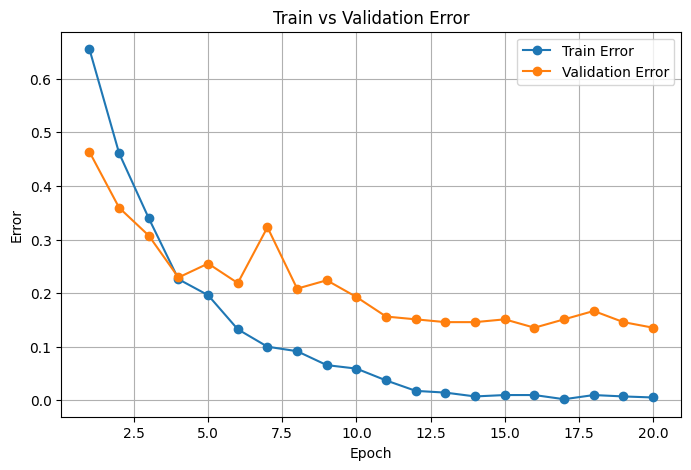

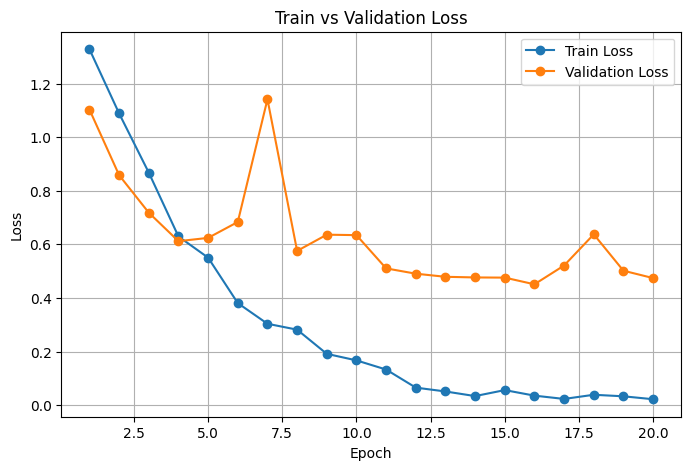

In [ ]:
#5th model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the fine-tuning model
ft_model5 = FineTunedR2Plus1D(num_classes=4, dropout_prob=0.6)
ft_model5 = ft_model5.to(device)

# Train the model using a low learning rate (1e-4) for full fine-tuning
ft_model5, train_losses, val_losses, train_accs, val_accs = train_r2plus1d_finetune(
    ft_model5,
    train_loader,
    val_loader,
    device,
    total_epochs=20,
    lr=1e-4,        # Low learning rate for fine-tuning
    batch_size=8,
    model_name_str="ft_model5"
)

# Plot the training curves
plot_training_curves(train_accs, val_accs, train_losses, val_losses)

**16) Print the confusion matrix of the best model**

In [19]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# --- CONFUSION MATRIX FUNCTION ---
FOCUSED_CLASSES = ["pass", "dribble", "shoot", "defense"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_predictions_and_labels(model, dataloader, device):
    """
    Runs inference on a given dataloader and collects all true and predicted labels.
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for videos, labels_batch in dataloader:
            videos = videos.to(device)

            # Runs the R2+1D backbone.
            outputs = model(videos)

            # Get the predicted class index (highest logit)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

def display_confusion_matrix(true_labels, predicted_labels, class_names):
    """
    Calculates and displays the confusion matrix and prints a classification report.
    """
    # 1. Calculate the Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    # 2. Plot the matrix
    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title("Confusion Matrix for Basketball Actions")
    plt.show()

    # 3. Print Classification Report (Precision, Recall, F1-Score)
    print("\n--- Classification Report ---")
    report = classification_report(true_labels, predicted_labels, target_names=class_names, zero_division=0)
    print(report)

<Figure size 1000x800 with 0 Axes>

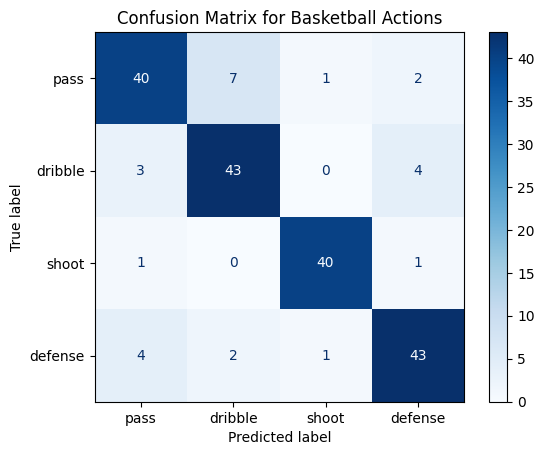


--- Classification Report ---
              precision    recall  f1-score   support

        pass       0.83      0.80      0.82        50
     dribble       0.83      0.86      0.84        50
       shoot       0.95      0.95      0.95        42
     defense       0.86      0.86      0.86        50

    accuracy                           0.86       192
   macro avg       0.87      0.87      0.87       192
weighted avg       0.86      0.86      0.86       192



In [21]:
#1. Instantiate and load the model
ft_model_final = FineTunedR2Plus1D(num_classes=4, dropout_prob=0.6)
best_model_path = "/content/drive/MyDrive/Colab_Notebooks/Project/train_r2plus1d_ft_model5_ep20_bs8_lr1e-04_acc0.8646.pth"
ft_model_final.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
ft_model_final.to(DEVICE)

# 2. Get predictions
true_labels, predicted_labels = get_predictions_and_labels(ft_model_final, val_loader, DEVICE)

# 3. Display results
display_confusion_matrix(true_labels, predicted_labels, FOCUSED_CLASSES)

In [ ]:
# 1. Zip the folder
!zip -r /content/checkpoints.zip /content/checkpoints

# 2. Download the zip file
from google.colab import files
files.download('/content/checkpoints.zip')

print("The checkpoints.zip file has been prepared for download.")

  adding: content/checkpoints/ (stored 0%)
  adding: content/checkpoints/train_r2plus1d_ep15_bs8_lr5e-05_acc0.7760.pth (deflated 7%)
  adding: content/checkpoints/train_r2plus1d_ft_model4_ep20_bs8_lr5e-05_acc0.8229.pth (deflated 7%)
  adding: content/checkpoints/train_r2plus1d_ft_model4_ep20_bs8_lr5e-05_acc0.7812.pth (deflated 7%)
  adding: content/checkpoints/train_r2plus1d_ep15_bs8_lr5e-05_acc0.8125.pth (deflated 7%)
  adding: content/checkpoints/train_r2plus1d_ep15_bs8_lr5e-05_acc0.8438.pth (deflated 7%)
  adding: content/checkpoints/train_r2plus1d_ep15_bs8_lr1e-04_acc0.7448.pth (deflated 7%)
  adding: content/checkpoints/train_r2plus1d_ft_model5_ep20_bs8_lr1e-04_acc0.8073.pth (deflated 7%)
  adding: content/checkpoints/train_r2plus1d_ep15_bs8_lr5e-05_acc0.5417.pth (deflated 7%)
  adding: content/checkpoints/train_r2plus1d_ep15_bs8_lr5e-05_acc0.6719.pth (deflated 7%)
  adding: content/checkpoints/train_r2plus1d_ft_model5_ep20_bs8_lr1e-04_acc0.6406.pth (deflated 7%)
  adding: content

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The checkpoints.zip file has been prepared for download.


**17) Test the Full Fine-Tuning Model: Training of Pre-Trained R(2+1)D-18 with RGB using the test data loader + Report the Accuracy**

In [23]:
# --- TEST THE FINAL MODEL ---
ft_model_final.to(DEVICE)
ft_model_final.eval() # Ensure it is explicitly in evaluation mode

# 2. Define Criterion and Classes
criterion = nn.CrossEntropyLoss()
FOCUSED_CLASSES = ["pass", "dribble", "shoot", "defense"]

# 3. Use the existing evaluate function for accuracy/loss on the Test Loader
test_acc, test_loss = evaluate(ft_model_final, test_loader, DEVICE, criterion)

print(f"\n--- FINAL TEST RESULTS ---")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")



--- FINAL TEST RESULTS ---
Test Loss: 0.5892
Test Accuracy: 0.8196 (81.96%)



--- Running Confusion Matrix on Test Set ---


<Figure size 1000x800 with 0 Axes>

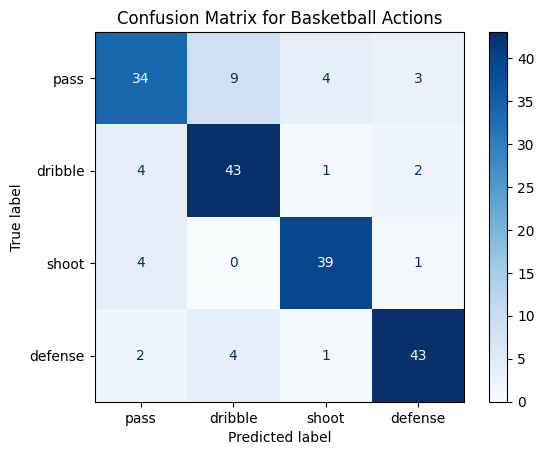


--- Classification Report ---
              precision    recall  f1-score   support

        pass       0.77      0.68      0.72        50
     dribble       0.77      0.86      0.81        50
       shoot       0.87      0.89      0.88        44
     defense       0.88      0.86      0.87        50

    accuracy                           0.82       194
   macro avg       0.82      0.82      0.82       194
weighted avg       0.82      0.82      0.82       194



In [24]:
# 4. Confusion matrix utility to check per-class performance on the Test Loader
print(f"\n--- Running Confusion Matrix on Test Set ---")
true_labels, predicted_labels = get_predictions_and_labels(ft_model_final, test_loader, DEVICE)
display_confusion_matrix(true_labels, predicted_labels, FOCUSED_CLASSES)

**18) Test the Best Model with new inseen data (Person doing: Pass, Dribble, Shoot, Defense) to see the model prediction**

In [3]:
# --- VIDEO PREDICTION SCRIPT ---
import torch
import numpy as np
from PIL import Image
import os
import io
import torchvision.transforms as transforms

# --- IMPORTANT: Colab Utility for Video (requires installation if not present) ---
#!pip install moviepy

from moviepy.editor import VideoFileClip
from google.colab import files

# --- CONFIGURATION ---
NUM_FRAMES = 16
FOCUSED_CLASSES = ["pass", "dribble", "shoot", "defense"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. PRE-PROCESSING SECTION  ---
# Re-use the exact transforms (Resize, ToTensor, Normalize) from your training pipeline
# 3-channel (RGB) input tensor now.
PRED_TRANSFORMS = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

def preprocess_video_clip(video_path):
    """
    Loads an MP4, extracts a fixed number of frames, converts to RGB,
    applies transformations, and prepares the final input tensor (C, D, H, W).
    """
    print(f"Loading video: {video_path}")

    try:
        clip = VideoFileClip(video_path)
    except Exception as e:
        print(f"Error loading video file: {e}")
        return None

    duration = clip.duration

    # Calculate extraction times to get 16 uniformly spaced frames
    # Use the time stamps (t) for extraction
    frame_times = np.linspace(0, duration, NUM_FRAMES, endpoint=True)

    frame_tensors = []

    for t in frame_times:
        try:
            # Get frame as a NumPy array (H, W, C)
            frame_array = clip.get_frame(t)

            # Convert NumPy array to PIL Image in RGB format
            frame_pil = Image.fromarray(frame_array).convert('RGB')

            # Apply the standard training transforms (Resize, ToTensor, Normalize)
            frame_tensor = PRED_TRANSFORMS(frame_pil)
            frame_tensors.append(frame_tensor)

        except Exception as e:
            # Handles cases where video duration might be shorter than expected
            print(f"Warning: Could not extract frame at time {t:.2f}s. Error: {e}")
            break

    clip.close()

    if not frame_tensors:
        return None

    # Stack tensors: shape (Depth, C, H, W) e.g., (16, 3, 64, 64)
    video_tensor = torch.stack(frame_tensors, dim=0)

    # Rearrange to the required 3D CNN format: (C, Depth, H, W) e.g., (3, 16, 64, 64)
    video_tensor = video_tensor.permute(1, 0, 2, 3)

    # Add batch dimension: (1, C, D, H, W)
    video_tensor = video_tensor.unsqueeze(0)

    return video_tensor

def predict_action(model, video_tensor):
    """
    Runs the input tensor through the loaded model and returns:
    1. The predicted class name (string).
    2. A dictionary of prediction percentages for all four classes.
    """
    if video_tensor is None:
        return "Prediction Failed (Invalid Input)", {}

    model.eval()
    with torch.no_grad():
        video_tensor = video_tensor.to(DEVICE)

        # Get the logits
        outputs = model(video_tensor)

        # 1. Convert logits to probabilities using Softmax
        probabilities = torch.softmax(outputs, dim=1)

        # 2. Get the predicted index and class name
        _, predicted_index = torch.max(probabilities.data, 1)
        predicted_class = FOCUSED_CLASSES[predicted_index.item()]

        # 3. Format the probabilities/percentages for all classes
        # probabilities[0] because batch size is 1
        probabilities_list = probabilities[0].cpu().numpy()

        # Create a dictionary mapping class name to percentage string
        prediction_percentages = {
            class_name: f"{prob * 100:.2f}%"
            for class_name, prob in zip(FOCUSED_CLASSES, probabilities_list)
        }

    return predicted_class, prediction_percentages

In [25]:
# --- EXAMPLE 1 EXECUTION BLOCK ---

# 1. Provide the exact path of MP4 file on my mounted Google Drive.
video_filename = '/content/drive/MyDrive/Colab_Notebooks/Project/shoot_MT_test.mp4'


#2. Preprocess the video
input_tensor = preprocess_video_clip(video_filename)

# 3. Load my best model
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ft_model_final = FineTunedR2Plus1D(num_classes=4, dropout_prob=0.6)
best_model_path = "/content/drive/MyDrive/Colab_Notebooks/Project/train_r2plus1d_ft_model5_ep20_bs8_lr1e-04_acc0.8646.pth"
ft_model_final.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
ft_model_final.to(DEVICE)

model_loaded = ft_model_final # Reuse the already loaded model

# 4. Predict
predicted_class, class_percentages = predict_action(model_loaded, input_tensor)

# 5. Print Results
print("---------------------------------------")
print(f"CLASSIFICATION RESULT: {predicted_class}")
print()
print("--- All Class Probabilities ---")
for name, percentage in class_percentages.items():
  print(f"  {name.ljust(10)}: {percentage}")
print("---------------------------------------")


Loading video: /content/drive/MyDrive/Colab_Notebooks/Project/shoot_MT_test.mp4
---------------------------------------
CLASSIFICATION RESULT: shoot

--- All Class Probabilities ---
  pass      : 2.25%
  dribble   : 0.64%
  shoot     : 96.77%
  defense   : 0.34%
---------------------------------------


In [6]:
# --- EXAMPLE 2 EXECUTION BLOCK ---

# 1. Provide the exact path of MP4 file on my mounted Google Drive.
video_filename = '/content/drive/MyDrive/Colab_Notebooks/Project/dribble_MT_test.mp4'


#2. Preprocess the video
input_tensor = preprocess_video_clip(video_filename)

# 3. Load my best model
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ft_model_final = FineTunedR2Plus1D(num_classes=4, dropout_prob=0.6)
best_model_path = "/content/drive/MyDrive/Colab_Notebooks/Project/train_r2plus1d_ft_model5_ep20_bs8_lr1e-04_acc0.8646.pth"
ft_model_final.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
ft_model_final.to(DEVICE)

model_loaded = ft_model_final # Reuse the already loaded model

# 4. Predict
predicted_class, class_percentages = predict_action(model_loaded, input_tensor)

# 5. Print Results
print("---------------------------------------")
print(f"CLASSIFICATION RESULT: {predicted_class}")
print()
print("--- All Class Probabilities ---")
for name, percentage in class_percentages.items():
  print(f"  {name.ljust(10)}: {percentage}")
print("---------------------------------------")


Loading video: /content/drive/MyDrive/Colab_Notebooks/Project/dribble_MT_test.mp4
---------------------------------------
CLASSIFICATION RESULT: dribble

--- All Class Probabilities ---
  pass      : 0.10%
  dribble   : 99.74%
  shoot     : 0.01%
  defense   : 0.15%
---------------------------------------
